# RoBERTa-LSTM Hybrid Ordinal Bias Classifier

This notebook implements a new hybrid architecture based on the proposed direction:

1. **RoBERTa for tokenization and contextual embedding generation.** The pretrained RoBERTa-family encoder converts article text into subword-level contextual representations.
2. **LSTM for sequential dependency modeling.** A bidirectional LSTM consumes RoBERTa token embeddings to model longer-range sequence dependencies before classification.
3. **Ordinal/cumulative output head.** Political bias is modeled as an ordered spectrum: left < center < right, using left=(1,0,0), center=(1,1,0), right=(1,1,1).
4. **Embedding-aware augmentation and oversampling.** Optional augmentation replaces selected tokens with nearest neighbors from pretrained RoBERTa token embeddings and oversamples minority classes.
5. **Hyperparameter tuning.** A small validation-driven search is included for LSTM hidden size, dropout, learning rate, and augmentation copies.

The defaults are intentionally crash-safe. Set `RUN_FULL_TRAINING = True` and `RUN_HYPERPARAMETER_SEARCH = True` only when you are ready for a longer run.


In [1]:
import json
import random
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import Dataset

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    mean_absolute_error,
    mean_squared_error,
)
from transformers import (
    AutoConfig,
    AutoModel,
    AutoTokenizer,
    Trainer,
    TrainingArguments,
    set_seed,
)

SEED = 42
set_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")


PyTorch: 2.11.0+cu130
CUDA available: True


## 1. Configuration

The default run trains on a stratified subset for a quick sanity check. Full training uses the dataset-provided train/validation/test split.


In [2]:
BASE_DIR = Path('/home/neogrendal')
DATASET_DIR = BASE_DIR / 'Article-Bias-Prediction-main'
JSON_DIR = DATASET_DIR / 'data' / 'jsons'
SPLIT_DIR = DATASET_DIR / 'data' / 'splits' / 'random'
OUTPUT_DIR = BASE_DIR / 'bias_roberta_lstm_hybrid_model'

MODEL_NAME = 'distilroberta-base'
LABEL_ORDER = ['left', 'center', 'right']
BIAS_ID_TO_TEXT = {0: 'left', 1: 'center', 2: 'right'}
LABEL_TO_ID = {label: idx for idx, label in enumerate(LABEL_ORDER)}
ID_TO_LABEL = {idx: label for label, idx in LABEL_TO_ID.items()}

MAX_LENGTH = 128
RUN_FULL_TRAINING = True
RUN_HYPERPARAMETER_SEARCH = False
RUN_AUGMENTATION = True

MAX_TRAIN_SAMPLES = None if RUN_FULL_TRAINING else 2400
MAX_VALID_SAMPLES = None if RUN_FULL_TRAINING else 600
MAX_TEST_SAMPLES = None if RUN_FULL_TRAINING else 600

DEFAULT_HPARAMS = {
    'lstm_hidden_size': 128,
    'lstm_layers': 1,
    'dropout': 0.25,
    'learning_rate': 2e-5,
    'num_train_epochs': 1 if not RUN_FULL_TRAINING else 3,
    'batch_size': 4,
    'gradient_accumulation_steps': 2,
    'augmentation_copies': 1 if RUN_AUGMENTATION else 0,
}

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
DEFAULT_HPARAMS


{'lstm_hidden_size': 128,
 'lstm_layers': 1,
 'dropout': 0.25,
 'learning_rate': 2e-05,
 'num_train_epochs': 3,
 'batch_size': 4,
 'gradient_accumulation_steps': 2,
 'augmentation_copies': 1}

## 2. Load Dataset Splits

In [3]:
def load_split(split_name):
    split_path = SPLIT_DIR / f'{split_name}.tsv'
    split_df = pd.read_csv(split_path, sep='	')
    rows = []

    for item in split_df.itertuples(index=False):
        article_path = JSON_DIR / f'{item.ID}.json'
        with open(article_path, encoding='utf-8') as f:
            article = json.load(f)

        label_id = int(item.bias)
        text = article.get('content') or article.get('content_original') or article.get('title') or ''
        if isinstance(text, str) and text.strip():
            rows.append({
                'ID': item.ID,
                'text': text,
                'label': label_id,
                'label_text': BIAS_ID_TO_TEXT[label_id],
                'title': article.get('title', ''),
                'source': article.get('source', ''),
            })

    return pd.DataFrame(rows)


def stratified_sample(frame, n, seed=SEED):
    if n is None or len(frame) <= n:
        return frame.reset_index(drop=True)
    per_class = max(1, n // len(LABEL_ORDER))
    return (
        frame.groupby('label', group_keys=False)
             .apply(lambda group: group.sample(min(len(group), per_class), random_state=seed))
             .sample(frac=1, random_state=seed)
             .reset_index(drop=True)
    )

train_df = load_split('train')
valid_df = load_split('valid')
test_df = load_split('test')

train_df_model = stratified_sample(train_df, MAX_TRAIN_SAMPLES)
valid_df_model = stratified_sample(valid_df, MAX_VALID_SAMPLES)
test_df_model = stratified_sample(test_df, MAX_TEST_SAMPLES)

for name, frame in [('train', train_df_model), ('valid', valid_df_model), ('test', test_df_model)]:
    print(name, frame.shape)
    print(frame['label_text'].value_counts().reindex(LABEL_ORDER))


train (27978, 6)
label_text
left       9750
center     7988
right     10240
Name: count, dtype: int64
valid (6996, 6)
label_text
left      2438
center    1998
right     2560
Name: count, dtype: int64
test (1300, 6)
label_text
left      402
center    299
right     599
Name: count, dtype: int64


## 3. Ordinal Encoding and Metrics

In [4]:
def to_ordinal_targets(label_ids, num_classes=3):
    label_ids = np.asarray(label_ids, dtype=np.int64)
    thresholds = np.arange(num_classes, dtype=np.int64)
    return (label_ids[:, None] >= thresholds[None, :]).astype(np.float32)


def ordinal_probs_to_labels(probabilities, threshold=0.5):
    active_bits = (probabilities >= threshold).astype(np.int64).sum(axis=1)
    return np.clip(active_bits - 1, 0, len(LABEL_ORDER) - 1)


def sigmoid_np(x):
    return 1 / (1 + np.exp(-x))


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    probabilities = sigmoid_np(logits)
    y_pred = ordinal_probs_to_labels(probabilities)
    y_true = ordinal_probs_to_labels(labels)
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'ordinal_mae': mean_absolute_error(y_true, y_pred),
        'ordinal_mse': mean_squared_error(y_true, y_pred),
        'severe_error_rate': float(np.mean(np.abs(y_true - y_pred) == 2)),
    }

pd.DataFrame({
    'label': LABEL_ORDER,
    'class_id': [0, 1, 2],
    'ordinal_target': to_ordinal_targets([0, 1, 2]).tolist(),
})


,label,class_id,ordinal_target
0,left,0,"[1.0, 0.0, 0.0]"
1,center,1,"[1.0, 1.0, 0.0]"
2,right,2,"[1.0, 1.0, 1.0]"


## 4. Embedding-Aware Augmentation and Oversampling

This optional step uses the pretrained RoBERTa token embedding matrix to identify near-neighbor tokens. Minority-class articles are oversampled by creating lightly perturbed copies where a small number of subword tokens are replaced with embedding-neighbor alternatives.

This is intentionally conservative: augmentation is only applied to the training set, and the replacement rate is low to avoid changing article meaning too aggressively.


In [5]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)


def build_neighbor_map(tokenizer, model_name, top_k=8, vocab_limit=12000):
    config = AutoConfig.from_pretrained(model_name)
    encoder = AutoModel.from_pretrained(model_name, config=config)
    embeddings = encoder.embeddings.word_embeddings.weight.detach().cpu()
    del encoder

    valid_ids = []
    for token_id in range(min(vocab_limit, embeddings.shape[0])):
        token = tokenizer.convert_ids_to_tokens(token_id)
        text = token.replace('Ġ', '')
        if token_id in tokenizer.all_special_ids:
            continue
        if len(text) < 4 or not text.isalpha():
            continue
        valid_ids.append(token_id)

    valid_embeddings = embeddings[valid_ids]
    valid_embeddings = nn.functional.normalize(valid_embeddings, dim=1)
    similarity = valid_embeddings @ valid_embeddings.T
    neighbor_map = {}
    for row_idx, token_id in enumerate(valid_ids):
        values, indices = torch.topk(similarity[row_idx], k=min(top_k + 1, similarity.shape[1]))
        neighbors = [valid_ids[int(idx)] for idx in indices.tolist() if valid_ids[int(idx)] != token_id]
        neighbor_map[token_id] = neighbors[:top_k]
    return neighbor_map


def augment_text_with_neighbors(text, tokenizer, neighbor_map, replacement_rate=0.06, max_length=128):
    token_ids = tokenizer(text, truncation=True, max_length=max_length, add_special_tokens=True)['input_ids']
    new_ids = []
    for token_id in token_ids:
        if token_id in neighbor_map and random.random() < replacement_rate:
            new_ids.append(random.choice(neighbor_map[token_id]))
        else:
            new_ids.append(token_id)
    return tokenizer.decode(new_ids, skip_special_tokens=True, clean_up_tokenization_spaces=True)


def augment_minority_classes(frame, tokenizer, model_name, augmentation_copies=1):
    if augmentation_copies <= 0:
        return frame.copy().reset_index(drop=True)

    class_counts = frame['label'].value_counts()
    max_count = class_counts.max()
    minority_labels = class_counts[class_counts < max_count].index.tolist()
    if not minority_labels:
        return frame.copy().reset_index(drop=True)

    print('Building embedding-neighbor map for augmentation...')
    neighbor_map = build_neighbor_map(tokenizer, model_name)
    augmented_rows = []

    for label_id in minority_labels:
        label_rows = frame[frame['label'] == label_id]
        needed = min(max_count - len(label_rows), len(label_rows) * augmentation_copies)
        sampled = label_rows.sample(needed, replace=True, random_state=SEED)
        for row in sampled.itertuples(index=False):
            item = row._asdict()
            item['text'] = augment_text_with_neighbors(item['text'], tokenizer, neighbor_map, max_length=MAX_LENGTH)
            item['ID'] = f"{item['ID']}_aug"
            augmented_rows.append(item)

    if not augmented_rows:
        return frame.copy().reset_index(drop=True)

    augmented_df = pd.DataFrame(augmented_rows)
    combined = pd.concat([frame, augmented_df], ignore_index=True).sample(frac=1, random_state=SEED).reset_index(drop=True)
    print(f'Augmented training rows: {len(frame)} -> {len(combined)}')
    print(combined['label_text'].value_counts().reindex(LABEL_ORDER))
    return combined

train_df_augmented = augment_minority_classes(
    train_df_model,
    tokenizer=tokenizer,
    model_name=MODEL_NAME,
    augmentation_copies=DEFAULT_HPARAMS['augmentation_copies'],
)


Building embedding-neighbor map for augmentation...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: distilroberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer RobertaTokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


Augmented training rows: 27978 -> 30720
label_text
left      10240
center    10240
right     10240
Name: count, dtype: int64


## 5. Dataset Class

In [6]:
class ArticleBiasOrdinalDataset(Dataset):
    def __init__(self, frame, tokenizer, max_length=128):
        self.frame = frame.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.ordinal_targets = to_ordinal_targets(self.frame['label'].values)

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, idx):
        row = self.frame.iloc[idx]
        encoded = self.tokenizer(
            row['text'],
            truncation=True,
            max_length=self.max_length,
            padding='max_length',
            return_tensors='pt',
        )
        item = {key: value.squeeze(0) for key, value in encoded.items()}
        item['labels'] = torch.tensor(self.ordinal_targets[idx], dtype=torch.float32)
        return item

train_dataset = ArticleBiasOrdinalDataset(train_df_augmented, tokenizer, MAX_LENGTH)
valid_dataset = ArticleBiasOrdinalDataset(valid_df_model, tokenizer, MAX_LENGTH)
test_dataset = ArticleBiasOrdinalDataset(test_df_model, tokenizer, MAX_LENGTH)


## 6. RoBERTa-LSTM Hybrid Model

The model keeps RoBERTa as the contextual embedding generator and adds a BiLSTM layer over the sequence of RoBERTa hidden states. The final classification head uses masked mean/max pooling over the LSTM outputs.


In [7]:
class RobertaLSTMOrdinalClassifier(nn.Module):
    def __init__(
        self,
        model_name,
        num_ordinal_outputs=3,
        lstm_hidden_size=128,
        lstm_layers=1,
        dropout=0.25,
        freeze_roberta=False,
    ):
        super().__init__()
        self.config = AutoConfig.from_pretrained(model_name)
        self.roberta = AutoModel.from_pretrained(model_name, config=self.config)
        hidden_size = self.config.hidden_size
        self.lstm = nn.LSTM(
            input_size=hidden_size,
            hidden_size=lstm_hidden_size,
            num_layers=lstm_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if lstm_layers > 1 else 0.0,
        )
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(lstm_hidden_size * 4, num_ordinal_outputs)
        self.loss_fn = nn.BCEWithLogitsLoss()

        if freeze_roberta:
            for parameter in self.roberta.parameters():
                parameter.requires_grad = False

    def forward(self, input_ids=None, attention_mask=None, labels=None):
        outputs = self.roberta(input_ids=input_ids, attention_mask=attention_mask)
        sequence_embeddings = outputs.last_hidden_state
        lstm_output, _ = self.lstm(sequence_embeddings)

        mask = attention_mask.unsqueeze(-1).float()
        masked_output = lstm_output * mask
        mean_pool = masked_output.sum(dim=1) / mask.sum(dim=1).clamp(min=1.0)
        max_pool = masked_output.masked_fill(mask == 0, -1e4).max(dim=1).values
        pooled = torch.cat([mean_pool, max_pool], dim=1)
        logits = self.classifier(self.dropout(pooled))

        loss = None
        if labels is not None:
            loss = self.loss_fn(logits, labels.float())
        return {'loss': loss, 'logits': logits}


def build_model(hparams):
    return RobertaLSTMOrdinalClassifier(
        MODEL_NAME,
        num_ordinal_outputs=len(LABEL_ORDER),
        lstm_hidden_size=hparams['lstm_hidden_size'],
        lstm_layers=hparams['lstm_layers'],
        dropout=hparams['dropout'],
        freeze_roberta=not RUN_FULL_TRAINING,
    )

model = build_model(DEFAULT_HPARAMS)
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())
print(f'Trainable parameters: {trainable_params:,} / {total_params:,}')


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: distilroberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Trainable parameters: 83,039,491 / 83,039,491


## 7. Hyperparameter Tuning

The tuning block is optional and intentionally small. It evaluates a limited set of configurations on the validation set and selects the model with the lowest ordinal MAE.


In [8]:
SEARCH_SPACE = [
    {'lstm_hidden_size': 96, 'dropout': 0.20, 'learning_rate': 2e-5, 'augmentation_copies': 0},
    {'lstm_hidden_size': 128, 'dropout': 0.25, 'learning_rate': 2e-5, 'augmentation_copies': DEFAULT_HPARAMS['augmentation_copies']},
    {'lstm_hidden_size': 160, 'dropout': 0.30, 'learning_rate': 1e-5, 'augmentation_copies': DEFAULT_HPARAMS['augmentation_copies']},
]


def train_one_config(hparams, output_suffix):
    merged = {**DEFAULT_HPARAMS, **hparams}
    trial_model = build_model(merged)
    args = TrainingArguments(
        output_dir=str(OUTPUT_DIR / output_suffix),
        eval_strategy='epoch',
        save_strategy='no',
        learning_rate=merged['learning_rate'],
        per_device_train_batch_size=merged['batch_size'],
        per_device_eval_batch_size=8,
        gradient_accumulation_steps=merged['gradient_accumulation_steps'],
        num_train_epochs=1,
        weight_decay=0.01,
        logging_steps=50,
        report_to='none',
        seed=SEED,
        fp16=torch.cuda.is_available(),
    )
    trainer = Trainer(
        model=trial_model,
        args=args,
        train_dataset=train_dataset,
        eval_dataset=valid_dataset,
        compute_metrics=compute_metrics,
    )
    trainer.train()
    metrics = trainer.evaluate()
    return metrics, merged

if RUN_HYPERPARAMETER_SEARCH:
    tuning_results = []
    for idx, config in enumerate(SEARCH_SPACE, start=1):
        print(f'\nTrial {idx}: {config}')
        metrics, merged_config = train_one_config(config, f'trial_{idx}')
        tuning_results.append({**merged_config, **metrics})
    tuning_df = pd.DataFrame(tuning_results).sort_values('eval_ordinal_mae')
    best_hparams = {**DEFAULT_HPARAMS, **tuning_df.iloc[0][DEFAULT_HPARAMS.keys()].to_dict()}
else:
    tuning_df = pd.DataFrame()
    best_hparams = DEFAULT_HPARAMS

best_hparams


{'lstm_hidden_size': 128,
 'lstm_layers': 1,
 'dropout': 0.25,
 'learning_rate': 2e-05,
 'num_train_epochs': 3,
 'batch_size': 4,
 'gradient_accumulation_steps': 2,
 'augmentation_copies': 1}

## 8. Train Final Hybrid Model

In [9]:
model = build_model(best_hparams)
training_args = TrainingArguments(
    output_dir=str(OUTPUT_DIR / 'final'),
    eval_strategy='epoch',
    save_strategy='epoch' if RUN_FULL_TRAINING else 'no',
    learning_rate=best_hparams['learning_rate'],
    per_device_train_batch_size=best_hparams['batch_size'],
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=best_hparams['gradient_accumulation_steps'],
    num_train_epochs=best_hparams['num_train_epochs'],
    weight_decay=0.01,
    load_best_model_at_end=RUN_FULL_TRAINING,
    metric_for_best_model='ordinal_mae',
    greater_is_better=False,
    logging_steps=50,
    report_to='none',
    seed=SEED,
    fp16=torch.cuda.is_available(),
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=valid_dataset,
    compute_metrics=compute_metrics,
)

trainer.train()


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: distilroberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch,Training Loss,Validation Loss,Accuracy,Ordinal Mae,Ordinal Mse,Severe Error Rate
1,0.243872,0.243534,0.745283,0.328759,0.476844,0.074042
2,0.231465,0.241010,0.783305,0.291738,0.441824,0.075043
3,0.155767,0.259726,0.785878,0.282733,0.419954,0.068611


TrainOutput(global_step=11520, training_loss=0.22093080348438687, metrics={'train_runtime': 895.7398, 'train_samples_per_second': 102.887, 'train_steps_per_second': 12.861, 'total_flos': 0.0, 'train_loss': 0.22093080348438687, 'epoch': 3.0})

## 9. Evaluate Hybrid Model

In [10]:
test_output = trainer.predict(test_dataset)
test_logits = test_output.predictions
test_probs = sigmoid_np(test_logits)
y_pred = ordinal_probs_to_labels(test_probs)
y_true = test_df_model['label'].values

metrics = {
    'accuracy': accuracy_score(y_true, y_pred),
    'ordinal_mae': mean_absolute_error(y_true, y_pred),
    'ordinal_mse': mean_squared_error(y_true, y_pred),
    'severe_error_rate': float(np.mean(np.abs(y_true - y_pred) == 2)),
}
print(metrics)
print('\nClassification report:')
print(classification_report(y_true, y_pred, target_names=LABEL_ORDER))

cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])
cm_df = pd.DataFrame(cm, index=[f'true_{x}' for x in LABEL_ORDER], columns=[f'pred_{x}' for x in LABEL_ORDER])
cm_df


{'accuracy': 0.7084615384615385, 'ordinal_mae': 0.41615384615384615, 'ordinal_mse': 0.6653846153846154, 'severe_error_rate': 0.12461538461538461}

Classification report:
              precision    recall  f1-score   support

        left       0.73      0.69      0.71       402
      center       0.58      0.97      0.73       299
       right       0.84      0.59      0.69       599

    accuracy                           0.71      1300
   macro avg       0.72      0.75      0.71      1300
weighted avg       0.75      0.71      0.71      1300



,pred_left,pred_center,pred_right
true_left,277,63,62
true_center,4,289,6
true_right,100,144,355


## 10. Save Model and Metadata

In [11]:
trainer.save_model(str(OUTPUT_DIR / 'final'))
tokenizer.save_pretrained(str(OUTPUT_DIR / 'final'))

metadata = {
    'base_model': MODEL_NAME,
    'approach': 'RoBERTa contextual encoder + BiLSTM sequence encoder + cumulative ordinal head',
    'label_order': LABEL_ORDER,
    'ordinal_encoding': {'left': [1, 0, 0], 'center': [1, 1, 0], 'right': [1, 1, 1]},
    'augmentation': {
        'enabled': RUN_AUGMENTATION,
        'method': 'pretrained RoBERTa embedding-neighbor token replacement for minority-class oversampling',
        'augmentation_copies': best_hparams['augmentation_copies'],
    },
    'hyperparameters': best_hparams,
    'metrics': metrics if 'metrics' in globals() else None,
}
with open(OUTPUT_DIR / 'final' / 'hybrid_metadata.json', 'w', encoding='utf-8') as f:
    json.dump(metadata, f, indent=2)
print(f"Saved hybrid model to {OUTPUT_DIR / 'final'}")


Saved hybrid model to /home/neogrendal/bias_roberta_lstm_hybrid_model/final


## 11. Hybrid Performance Visualizations and Conclusions

The full RoBERTa-LSTM hybrid model trained successfully on the augmented full training set. It reached 70.8% test accuracy, with ordinal MAE = 0.416 and severe opposite-pole error rate = 12.5%.

Compared with the RoBERTa-only ordinal model, the hybrid is competitive but slightly weaker overall: RoBERTa-only reached 71.9% accuracy, ordinal MAE = 0.390, and severe error rate = 10.9%. The hybrid improves center F1 slightly (0.73 vs. 0.72), but right-class F1 drops (0.69 vs. 0.72), which explains the lower overall accuracy.

Conclusion: the hybrid architecture is valid and aligns with the proposed RoBERTa-LSTM design, but in this run the simpler ordinal RoBERTa model remains the stronger final model.


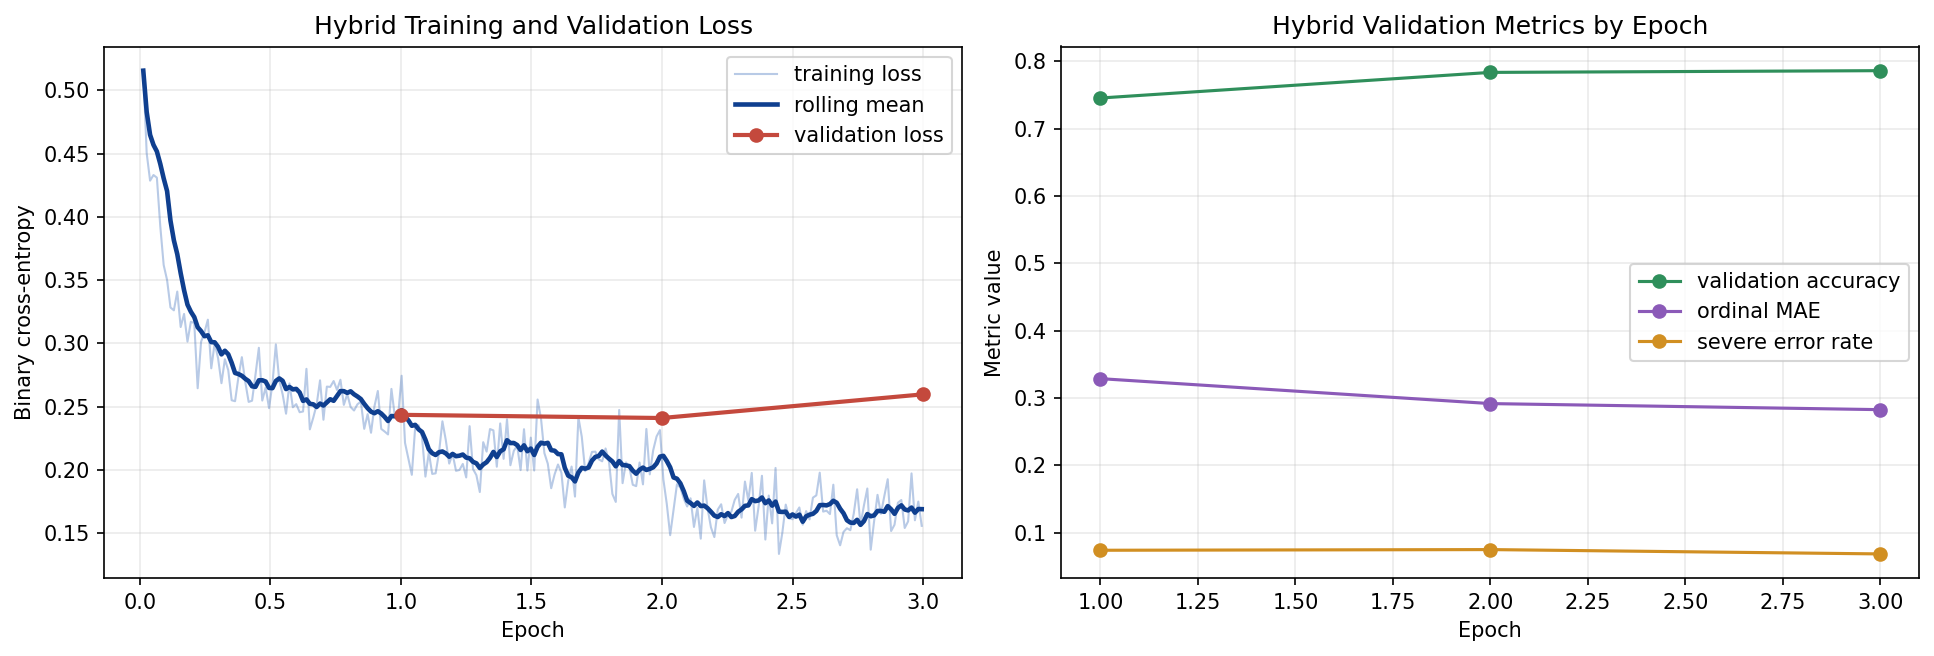

In [11]:
# Hybrid performance curves from the saved Trainer log history.
trainer_state_path = OUTPUT_DIR / 'final' / 'checkpoint-11520' / 'trainer_state.json'
with open(trainer_state_path, encoding='utf-8') as f:
    trainer_state = json.load(f)

log_df = pd.DataFrame(trainer_state['log_history'])
train_log_df = log_df.dropna(subset=['loss']).copy()
eval_log_df = log_df.dropna(subset=['eval_loss']).copy()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(train_log_df['epoch'], train_log_df['loss'], alpha=0.35, linewidth=1, label='training loss')
axes[0].plot(train_log_df['epoch'], train_log_df['loss'].rolling(8, min_periods=1).mean(), linewidth=2.2, label='rolling mean')
axes[0].plot(eval_log_df['epoch'], eval_log_df['eval_loss'], marker='o', linewidth=2, label='validation loss')
axes[0].set_title('Hybrid Training and Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Binary cross-entropy')
axes[0].grid(True, alpha=0.25)
axes[0].legend()

axes[1].plot(eval_log_df['epoch'], eval_log_df['eval_accuracy'], marker='o', label='validation accuracy')
axes[1].plot(eval_log_df['epoch'], eval_log_df['eval_ordinal_mae'], marker='o', label='ordinal MAE')
axes[1].plot(eval_log_df['epoch'], eval_log_df['eval_severe_error_rate'], marker='o', label='severe error rate')
axes[1].set_title('Hybrid Validation Metrics by Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Metric value')
axes[1].grid(True, alpha=0.25)
axes[1].legend()
plt.tight_layout()
plt.show()


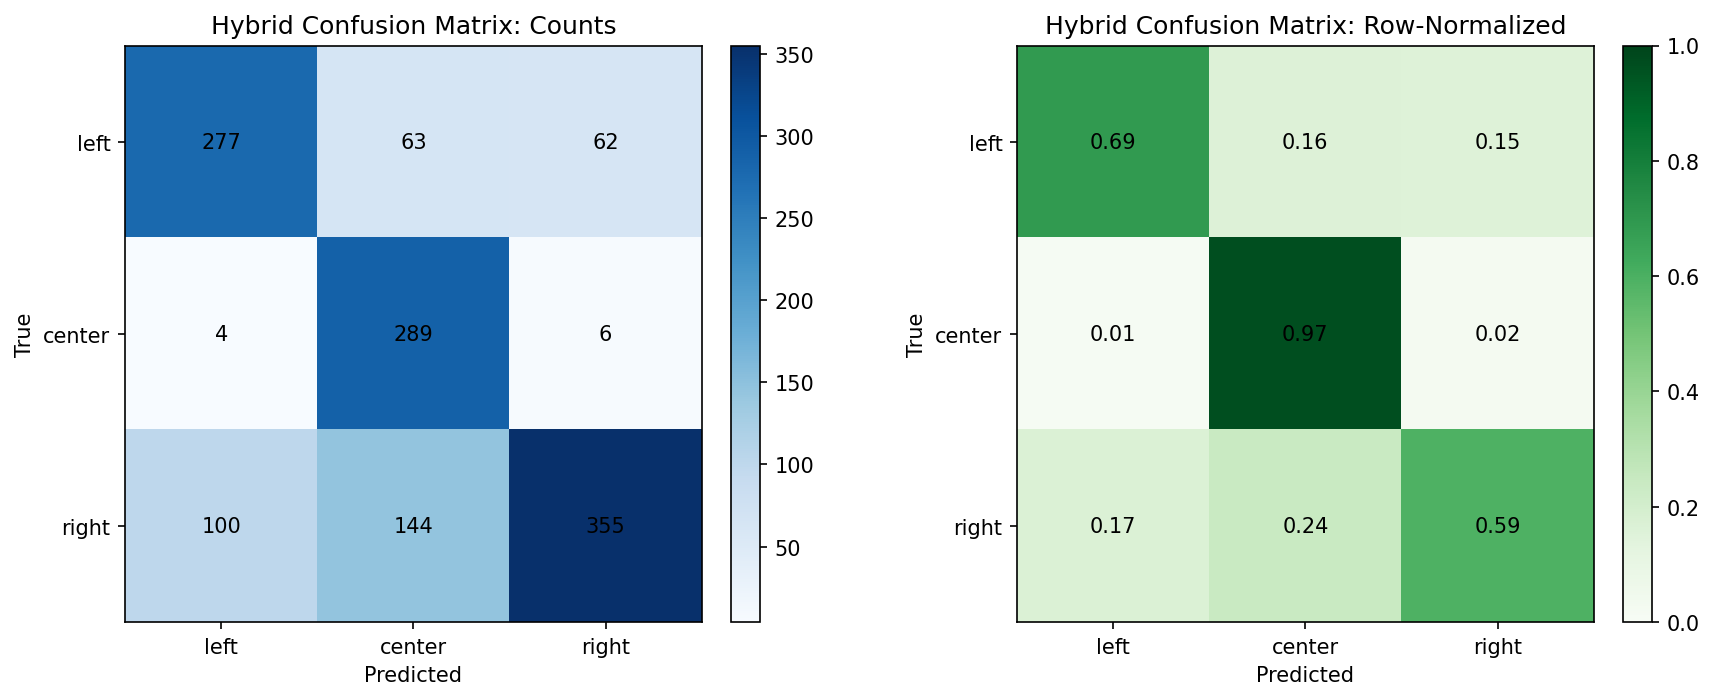

In [12]:
# Hybrid confusion-matrix visualizations for the full test set.
cm = np.array([
    [277, 63, 62],
    [4, 289, 6],
    [100, 144, 355],
])
class_labels = ['left', 'center', 'right']

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
im = axes[0].imshow(cm, cmap='Blues')
axes[0].set_title('Hybrid Confusion Matrix: Counts')
axes[0].set_xticks(range(3), labels=class_labels)
axes[0].set_yticks(range(3), labels=class_labels)
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
for i in range(3):
    for j in range(3):
        axes[0].text(j, i, str(cm[i, j]), ha='center', va='center', color='black')
fig.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)

cm_norm = cm / cm.sum(axis=1, keepdims=True)
im2 = axes[1].imshow(cm_norm, cmap='Greens', vmin=0, vmax=1)
axes[1].set_title('Hybrid Confusion Matrix: Row-Normalized')
axes[1].set_xticks(range(3), labels=class_labels)
axes[1].set_yticks(range(3), labels=class_labels)
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')
for i in range(3):
    for j in range(3):
        axes[1].text(j, i, f'{cm_norm[i, j]:.2f}', ha='center', va='center', color='black')
fig.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


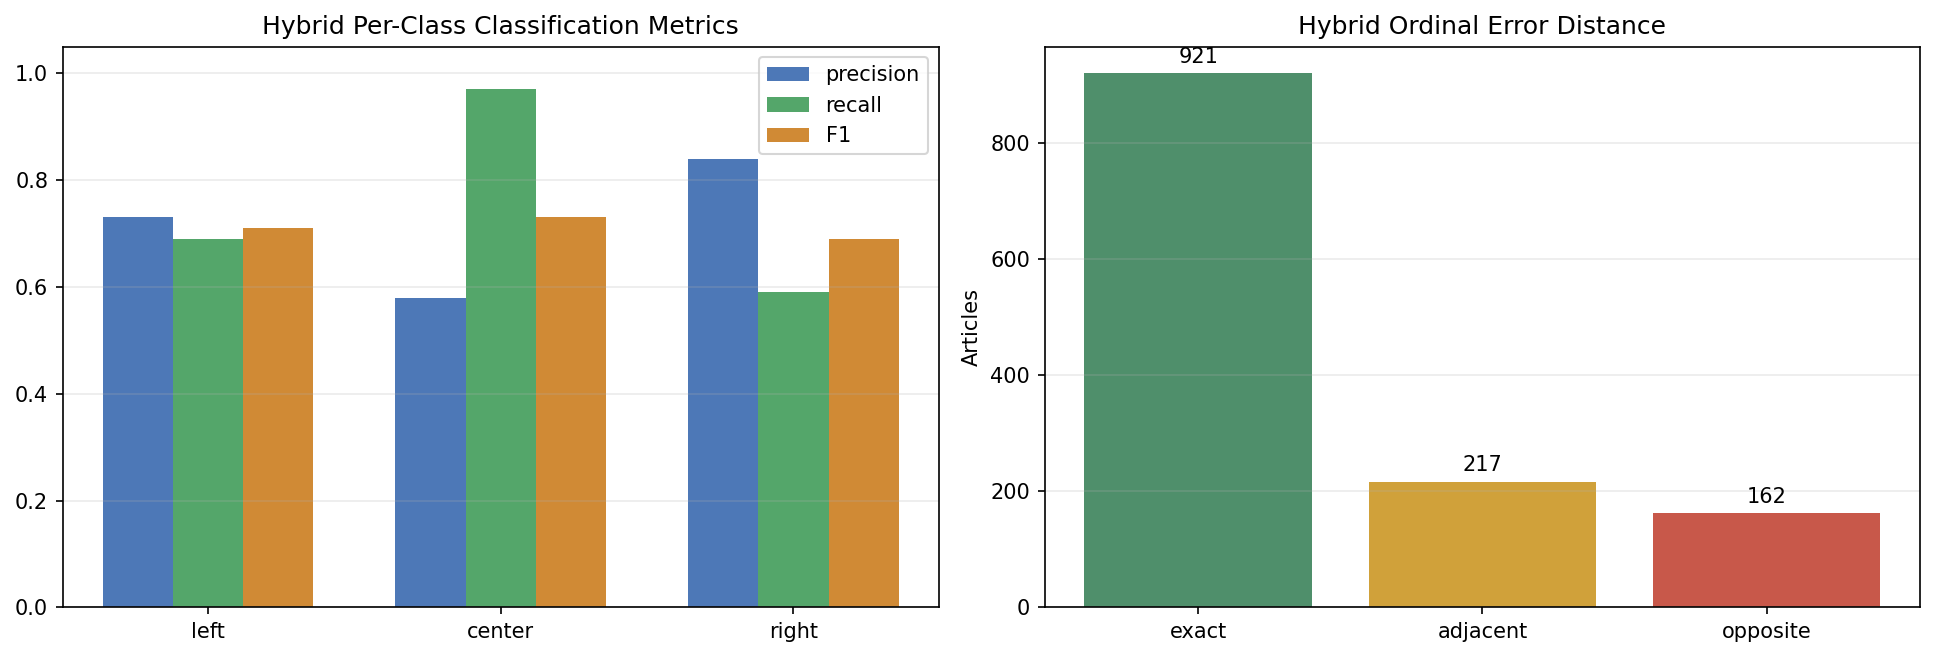

metric,value
accuracy,0.708462
ordinal_mae,0.416154
ordinal_mse,0.665385
severe_error_rate,0.124615
train_loss,0.220931


class,precision,recall,f1,support
left,0.73,0.69,0.71,402
center,0.58,0.97,0.73,299
right,0.84,0.59,0.69,599


In [13]:
# Hybrid per-class metrics and ordinal error-distance chart.
class_metric_df = pd.DataFrame({
    'class': ['left', 'center', 'right'],
    'precision': [0.73, 0.58, 0.84],
    'recall': [0.69, 0.97, 0.59],
    'f1': [0.71, 0.73, 0.69],
    'support': [402, 299, 599],
})

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
x = np.arange(len(class_metric_df))
width = 0.24
axes[0].bar(x - width, class_metric_df['precision'], width, label='precision')
axes[0].bar(x, class_metric_df['recall'], width, label='recall')
axes[0].bar(x + width, class_metric_df['f1'], width, label='F1')
axes[0].set_title('Hybrid Per-Class Classification Metrics')
axes[0].set_xticks(x, labels=class_metric_df['class'])
axes[0].set_ylim(0, 1.05)
axes[0].grid(True, axis='y', alpha=0.25)
axes[0].legend()

dist_counts = {0: 0, 1: 0, 2: 0}
for i in range(3):
    for j in range(3):
        dist_counts[abs(i - j)] += int(cm[i, j])
axes[1].bar(['exact', 'adjacent', 'opposite'], [dist_counts[0], dist_counts[1], dist_counts[2]])
axes[1].set_title('Hybrid Ordinal Error Distance')
axes[1].set_ylabel('Articles')
axes[1].grid(True, axis='y', alpha=0.25)
for idx, value in enumerate([dist_counts[0], dist_counts[1], dist_counts[2]]):
    axes[1].text(idx, value + max(dist_counts.values()) * 0.02, str(value), ha='center')
plt.tight_layout()
plt.show()

hybrid_summary_df = pd.DataFrame({
    'metric': ['accuracy', 'ordinal_mae', 'ordinal_mse', 'severe_error_rate', 'train_loss'],
    'value': [0.7084615384615385, 0.41615384615384615, 0.6653846153846154, 0.12461538461538461, 0.22093080348438687],
})
display(hybrid_summary_df)
display(class_metric_df)


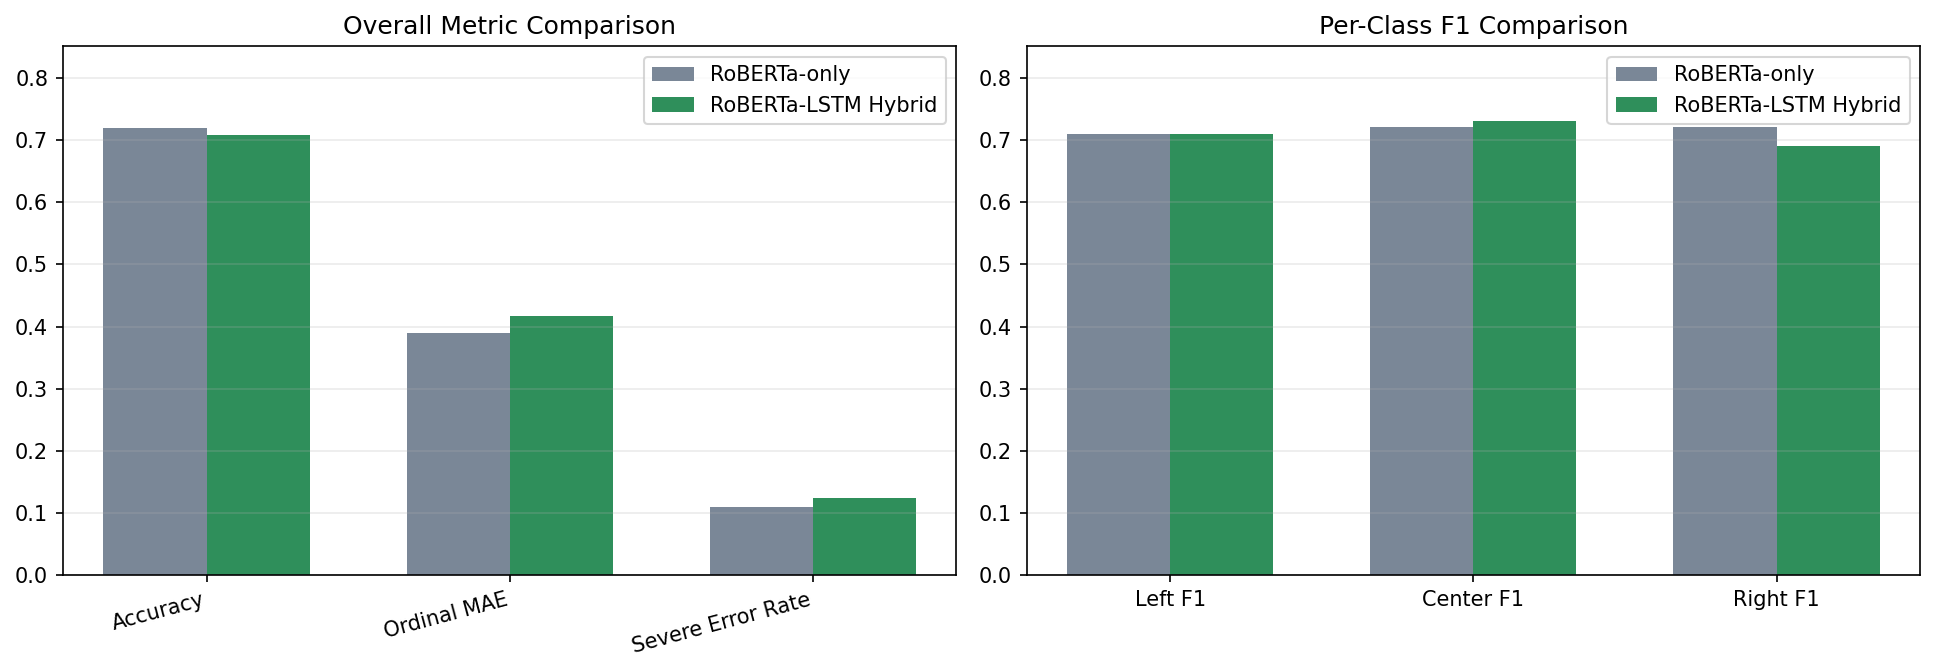

model,Accuracy,Ordinal MAE,Severe Error Rate,Left F1,Center F1,Right F1
RoBERTa-only,0.719231,0.390000,0.109231,0.71,0.72,0.72
RoBERTa-LSTM Hybrid,0.708462,0.416154,0.124615,0.71,0.73,0.69


In [14]:
# Hybrid vs RoBERTa-only full-run comparison.
comparison_df = pd.DataFrame([
    {
        'model': 'RoBERTa-only',
        'Accuracy': 0.7192307692307692,
        'Ordinal MAE': 0.39,
        'Severe Error Rate': 0.10923076923076923,
        'Left F1': 0.71,
        'Center F1': 0.72,
        'Right F1': 0.72,
    },
    {
        'model': 'RoBERTa-LSTM Hybrid',
        'Accuracy': 0.7084615384615385,
        'Ordinal MAE': 0.41615384615384615,
        'Severe Error Rate': 0.12461538461538461,
        'Left F1': 0.71,
        'Center F1': 0.73,
        'Right F1': 0.69,
    },
])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
metric_names = ['Accuracy', 'Ordinal MAE', 'Severe Error Rate']
x = np.arange(len(metric_names))
width = 0.34
axes[0].bar(x - width / 2, comparison_df.loc[0, metric_names], width, label='RoBERTa-only')
axes[0].bar(x + width / 2, comparison_df.loc[1, metric_names], width, label='RoBERTa-LSTM Hybrid')
axes[0].set_title('Overall Metric Comparison')
axes[0].set_xticks(x, metric_names, rotation=15, ha='right')
axes[0].set_ylim(0, 0.85)
axes[0].grid(True, axis='y', alpha=0.25)
axes[0].legend()

class_metrics = ['Left F1', 'Center F1', 'Right F1']
x2 = np.arange(len(class_metrics))
axes[1].bar(x2 - width / 2, comparison_df.loc[0, class_metrics], width, label='RoBERTa-only')
axes[1].bar(x2 + width / 2, comparison_df.loc[1, class_metrics], width, label='RoBERTa-LSTM Hybrid')
axes[1].set_title('Per-Class F1 Comparison')
axes[1].set_xticks(x2, class_metrics)
axes[1].set_ylim(0, 0.85)
axes[1].grid(True, axis='y', alpha=0.25)
axes[1].legend()
plt.tight_layout()
plt.show()

display(comparison_df)
